In [1]:
import scipy.io
import numpy as np
import os

# Path to your dataset folder
dataset_path = "E:\\RF FINGERPRINTING\\dataset\\"
all_data = {}
device_files = [f"Device_{i}.mat" for i in range(1, 11)]

print("Loading data...")

for file_name in device_files:
    file_path = os.path.join(dataset_path, file_name)
    
    # Load the .mat file
    mat_data = scipy.io.loadmat(file_path)
    
    # --- This is the important part ---
    # A .mat file is a dictionary. We need to find the key for the data.
    # Let's print the keys to find the right one. 
    # It's probably not '__header__', '__version__', or '__globals__'.
    
    data_key = None
    for key in mat_data.keys():
        if not key.startswith('__'):
            data_key = key
            break
            
    if data_key:
        print(f"Loaded {file_name} (data key: '{data_key}')")
        # Store the data array in our dictionary
        all_data[file_name] = mat_data[data_key]
    else:
        print(f"Could not find data key in {file_name}")

# Now, 'all_data' is a dictionary like:
# {'Device_1.mat': array(...), 'Device_2.mat': array(...), ...}
print(f"\nSuccessfully loaded {len(all_data)} device files.")

# Example: Check the shape of the data for Device 1
# This should be (19920, 72) or (19920, 72, 2) or something similar
print(f"Raw shape for Device 1: {all_data['Device_1.mat'].shape}")

Loading data...
Loaded Device_1.mat (data key: 'headerIQMatrix')
Loaded Device_2.mat (data key: 'headerIQMatrix')
Loaded Device_3.mat (data key: 'headerIQMatrix')
Loaded Device_4.mat (data key: 'headerIQMatrix')
Loaded Device_5.mat (data key: 'headerIQMatrix')
Loaded Device_6.mat (data key: 'headerIQMatrix')
Loaded Device_7.mat (data key: 'headerIQMatrix')
Loaded Device_8.mat (data key: 'headerIQMatrix')
Loaded Device_9.mat (data key: 'headerIQMatrix')
Loaded Device_10.mat (data key: 'headerIQMatrix')

Successfully loaded 10 device files.
Raw shape for Device 1: (19920, 72)


In [3]:
import scipy.io
import numpy as np
import os

# --- 1. Load Data (from your previous step) ---
dataset_path = "E:\\RF FINGERPRINTING\\dataset\\"
all_data = {}
device_files = [f"Device_{i}.mat" for i in range(1, 11)]

print("Loading data...")
for file_name in device_files:
    file_path = os.path.join(dataset_path, file_name)
    mat_data = scipy.io.loadmat(file_path)
    # The key is 'headerIQMatrix' as you discovered
    all_data[file_name] = mat_data['headerIQMatrix']

print(f"Successfully loaded {len(all_data)} device files.")
print(f"Raw shape for Device 1: {all_data['Device_1.mat'].shape}\n")

# --- 2. Preprocessing: Split I/Q and Merge ---

num_frames_to_merge = 10  # As specified in the paper
processed_data = {}

print("Preprocessing data...")
for device_name, complex_data in all_data.items():
    
    # Step 2a: Split complex data into Real (I) and Imaginary (Q)
    # np.real() gets the In-phase component
    # np.imag() gets the Quadrature component
    
    i_data = np.real(complex_data)  # Shape: (19920, 72)
    q_data = np.imag(complex_data)  # Shape: (19920, 72)
    
    # Stack them along a new last axis to create the (I, Q) pairs
    # Shape becomes: (19920, 72, 2)
    iq_data = np.stack([i_data, q_data], axis=-1)

    # Step 2b: Merge 10 consecutive frames
    
    # Get total frames (19920) and samples per frame (72)
    total_frames = iq_data.shape[0]
    samples_per_frame = iq_data.shape[1] # 72
    iq_dim = iq_data.shape[2] # 2

    # Calculate new number of frames (19920 // 10 = 1992)
    new_num_frames = total_frames // num_frames_to_merge
    
    # Truncate any extra frames (though 19920 is perfectly divisible)
    truncated_data = iq_data[:new_num_frames * num_frames_to_merge]
    
    # Reshape to group frames by 10
    # Shape -> (1992, 10, 72, 2)
    reshaped_data = truncated_data.reshape(new_num_frames,
                                           num_frames_to_merge,
                                           samples_per_frame,
                                           iq_dim)
                                           
    # Merge the 10 frames into one large frame (10 * 72 = 720)
    # Shape -> (1992, 720, 2)
    merged_data = reshaped_data.reshape(new_num_frames,
                                        num_frames_to_merge * samples_per_frame,
                                        iq_dim)
    
    # Store the final processed data for this device
    processed_data[device_name] = merged_data
    print(f"Processed {device_name}: New shape {merged_data.shape}")

print("\nAll data has been preprocessed.")

Loading data...
Successfully loaded 10 device files.
Raw shape for Device 1: (19920, 72)

Preprocessing data...
Processed Device_1.mat: New shape (1992, 720, 2)
Processed Device_2.mat: New shape (1992, 720, 2)
Processed Device_3.mat: New shape (1992, 720, 2)
Processed Device_4.mat: New shape (1992, 720, 2)
Processed Device_5.mat: New shape (1992, 720, 2)
Processed Device_6.mat: New shape (1992, 720, 2)
Processed Device_7.mat: New shape (1992, 720, 2)
Processed Device_8.mat: New shape (1992, 720, 2)
Processed Device_9.mat: New shape (1992, 720, 2)
Processed Device_10.mat: New shape (1992, 720, 2)

All data has been preprocessed.


In [4]:
import numpy as np

# --- 3. Create Training, Validation, and Test Sets ---

# Define which devices are which
known_device_keys = ['Device_1.mat', 'Device_2.mat', 'Device_5.mat', 
                     'Device_6.mat', 'Device_7.mat', 'Device_8.mat', 'Device_9.mat']
unknown_device_keys = ['Device_3.mat', 'Device_4.mat']
validation_device_key = 'Device_10.mat'

# --- 3a. Create the 'Known Device' pool ---
# We will use this to make training, validation (known), and test (known) sets
X_known_list = []
y_known_list = []

# Use a simple integer label for each known device
for label, key in enumerate(known_device_keys):
    device_data = processed_data[key]
    X_known_list.append(device_data)
    y_known_list.append(np.full(device_data.shape[0], label))

# Concatenate all 'known' data into one big array
X_known_pool = np.concatenate(X_known_list, axis=0)
y_known_pool = np.concatenate(y_known_list, axis=0)

# Total frames from 7 devices: 7 * 1992 = 13944 frames
# Shape should be (13944, 720, 2)
print(f"\nCreated 'Known Device' pool.")
print(f"X_known_pool shape: {X_known_pool.shape}")
print(f"y_known_pool shape: {y_known_pool.shape}")


# --- 3b. Split the 'Known Device' pool ---
# The paper uses a 70% / 10% / 20% split
# We'll use sklearn's train_test_split (you may need to 'pip install scikit-learn')
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temp (for test/validation)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_known_pool, y_known_pool, test_size=0.3, random_state=42, stratify=y_known_pool
)

# Second split: Split the 30% temp into 10% validation and 20% test
# (0.33 * 30% = ~10% validation, 0.67 * 30% = ~20% test)
X_val_known, X_test_known, y_val_known, y_test_known = train_test_split(
    X_temp, y_temp, test_size=0.67, random_state=42, stratify=y_temp
)

print(f"\n--- Training Set (Known) ---")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"--- Validation Set (Known) ---")
print(f"X_val_known shape: {X_val_known.shape}, y_val_known shape: {y_val_known.shape}")
print(f"--- Test Set (Known) ---")
print(f"X_test_known shape: {X_test_known.shape}, y_test_known shape: {y_test_known.shape}")


# --- 3c. Create the final Validation and Test sets ---

# The full validation set includes all of Device 10 (the validation device)
X_val_unknown = processed_data[validation_device_key]
# Give it a new label (e.g., 7) to mark it as unknown
y_val_unknown = np.full(X_val_unknown.shape[0], 7) 

X_validation_final = np.concatenate([X_val_known, X_val_unknown], axis=0)
y_validation_final = np.concatenate([y_val_known, y_val_unknown], axis=0)

print(f"\n--- Final Validation Set (Known + Unknown Device 10) ---")
print(f"X_validation_final shape: {X_validation_final.shape}")


# The full test set includes all unknown devices (3 and 4)
X_test_unknown_list = [processed_data[key] for key in unknown_device_keys]
X_test_unknown = np.concatenate(X_test_unknown_list, axis=0)
# Give them all the 'unknown' label (e.g., 7)
y_test_unknown = np.full(X_test_unknown.shape[0], 7)

X_test_final = np.concatenate([X_test_known, X_test_unknown], axis=0)
y_test_final = np.concatenate([y_test_known, y_test_unknown], axis=0)

print(f"\n--- Final Test Set (Known + Unknown Devices 3 & 4) ---")
print(f"X_test_final shape: {X_test_final.shape}")


Created 'Known Device' pool.
X_known_pool shape: (13944, 720, 2)
y_known_pool shape: (13944,)

--- Training Set (Known) ---
X_train shape: (9760, 720, 2), y_train shape: (9760,)
--- Validation Set (Known) ---
X_val_known shape: (1380, 720, 2), y_val_known shape: (1380,)
--- Test Set (Known) ---
X_test_known shape: (2804, 720, 2), y_test_known shape: (2804,)

--- Final Validation Set (Known + Unknown Device 10) ---
X_validation_final shape: (3372, 720, 2)

--- Final Test Set (Known + Unknown Devices 3 & 4) ---
X_test_final shape: (6788, 720, 2)


Loading data for constellation plot...
Loaded Device_1.mat
Loaded Device_2.mat
Loaded Device_3.mat

Saved 'constellation_plot_fixed.png'


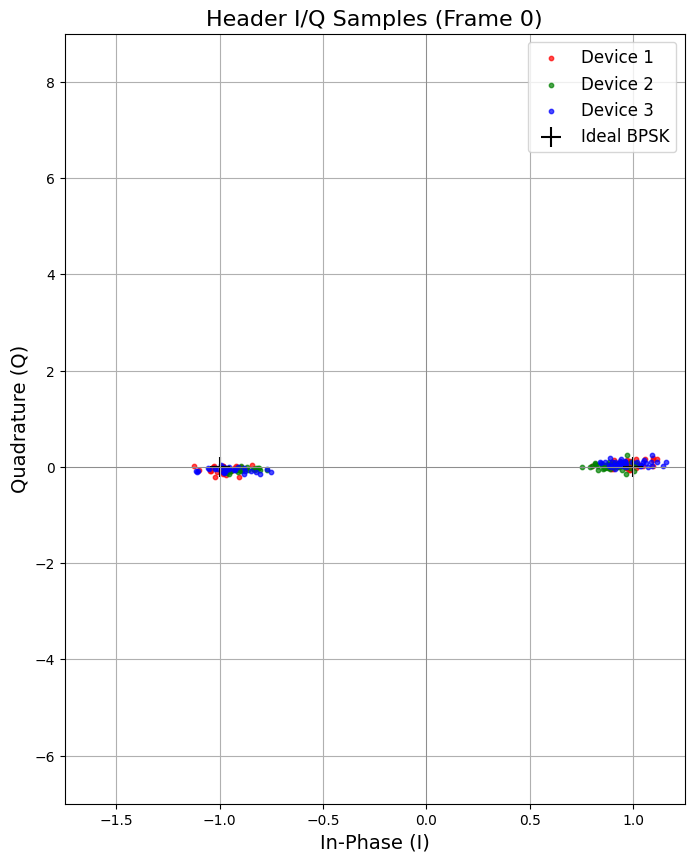

In [11]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. Load Raw Data ---
dataset_path = "E:\\RF FINGERPRINTING\\dataset\\"
devices_to_plot = ['Device_1.mat', 'Device_2.mat', 'Device_3.mat']
colors = ['red', 'green', 'blue']
device_data = {}

print("Loading data for constellation plot...")
for device_name in devices_to_plot:
    file_path = os.path.join(dataset_path, device_name)
    mat_data = scipy.io.loadmat(file_path)
    device_data[device_name] = mat_data['headerIQMatrix']
    print(f"Loaded {device_name}")

# --- 2. Select One Frame and Plot ---

# The paper shows 'one frame'. They likely picked one that
# was very spread out. Try changing this number (e.g., 10, 50, 100)
# to find a frame that matches the paper's example.
frame_index_to_plot = 0 

plt.figure(figsize=(8, 10)) # You can make this (10, 10) for more stretch
ax = plt.gca() 

for i, device_name in enumerate(devices_to_plot):
    frame_complex = device_data[device_name][frame_index_to_plot, :]
    i_data = np.real(frame_complex)
    q_data = np.imag(frame_complex)
    ax.scatter(i_data, q_data, label=f"Device {i+1}", color=colors[i], alpha=0.7, s=10)

# Plot the 'Ideal BPSK' points
ax.scatter([-1, 1], [0, 0], marker='+', color='black', s=200, label='Ideal BPSK')

# --- 3. Add Labels and **FIXED** Limits ---
ax.set_title(f'Header I/Q Samples (Frame {frame_index_to_plot})', fontsize=16)
ax.set_xlabel('In-Phase (I)', fontsize=14)
ax.set_ylabel('Quadrature (Q)', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True)
ax.axhline(0, color='grey', lw=0.5)
ax.axvline(0, color='grey', lw=0.5)

# --- THIS IS THE FIX ---
# Set limits to match the paper's (Figure 4)
ax.set_xlim(-1.75, 1.25)  # Paper's X-axis is roughly this
ax.set_ylim(-7, 9)        # Paper's Y-axis is large and stretched

# Force matplotlib to use these stretched axes
ax.set_aspect('auto') 
# -----------------------

plt.savefig('constellation_plot_fixed.png')
print("\nSaved 'constellation_plot_fixed.png'")
plt.show()

Loading data for constellation plot...
Loaded Device_1.mat
Loaded Device_2.mat
Loaded Device_3.mat

Saved 'constellation_plot_zoomed.png'


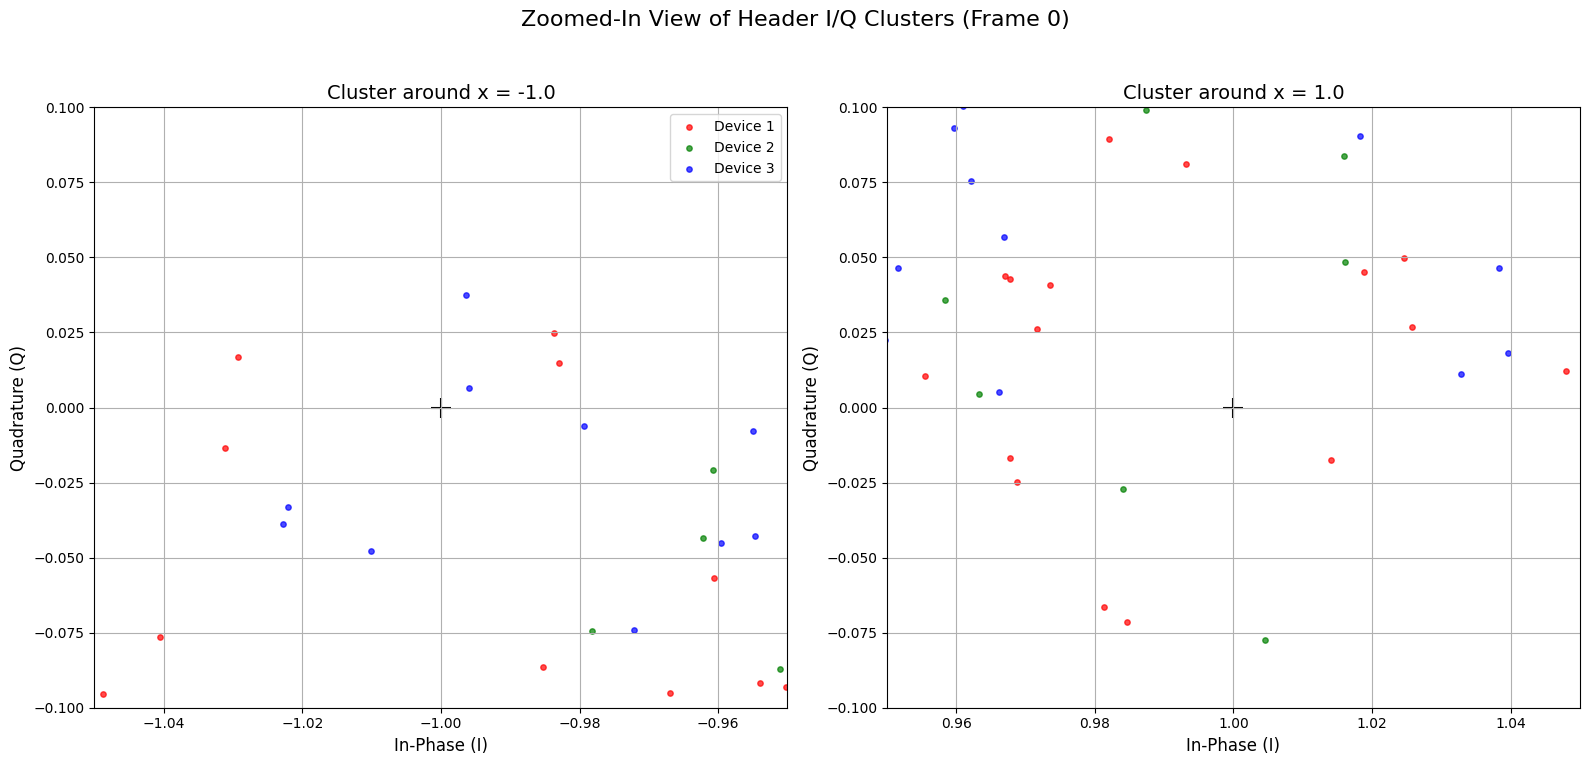

In [14]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. Load Raw Data ---
dataset_path = "E:\\RF FINGERPRINTING\\dataset\\"
devices_to_plot = ['Device_1.mat', 'Device_2.mat', 'Device_3.mat']
colors = ['red', 'green', 'blue']
device_data = {}

print("Loading data for constellation plot...")
for device_name in devices_to_plot:
    file_path = os.path.join(dataset_path, device_name)
    mat_data = scipy.io.loadmat(file_path)
    device_data[device_name] = mat_data['headerIQMatrix']
    print(f"Loaded {device_name}")

# --- 2. Select One Frame and Plot ---
# We will use two subplots to zoom in on each cluster
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Zoomed-In View of Header I/Q Clusters (Frame 0)', fontsize=16)

frame_index_to_plot = 0 

for i, device_name in enumerate(devices_to_plot):
    frame_complex = device_data[device_name][frame_index_to_plot, :]
    i_data = np.real(frame_complex)
    q_data = np.imag(frame_complex)
    
    # Plot on both subplots
    ax1.scatter(i_data, q_data, label=f"Device {i+1}", color=colors[i], alpha=0.7, s=15)
    ax2.scatter(i_data, q_data, color=colors[i], alpha=0.7, s=15) # No duplicate legend

# --- 3. Format Plot 1 (Left Cluster) ---
ax1.set_title('Cluster around x = -1.0', fontsize=14)
ax1.set_xlabel('In-Phase (I)', fontsize=12)
ax1.set_ylabel('Quadrature (Q)', fontsize=12)
ax1.legend()
ax1.grid(True)
# Zoom in on the left cluster
ax1.set_xlim(-1.05, -0.95)
ax1.set_ylim(-0.1, 0.1)
# Plot ideal point
ax1.scatter([-1], [0], marker='+', color='black', s=200, label='Ideal BPSK')

# --- 4. Format Plot 2 (Right Cluster) ---
ax2.set_title('Cluster around x = 1.0', fontsize=14)
ax2.set_xlabel('In-Phase (I)', fontsize=12)
ax2.set_ylabel('Quadrature (Q)', fontsize=12)
ax2.grid(True)
# Zoom in on the right cluster
ax2.set_xlim(0.95, 1.05)
ax2.set_ylim(-0.1, 0.1)
# Plot ideal point
ax2.scatter([1], [0], marker='+', color='black', s=200, label='Ideal BPSK')


plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust for suptitle
plt.savefig('constellation_plot_zoomed.png')
print("\nSaved 'constellation_plot_zoomed.png'")
plt.show()

Loading data for distribution plots...
Loaded and flattened Device_1.mat
Loaded and flattened Device_2.mat
Loaded and flattened Device_3.mat
Loaded and flattened Device_4.mat
Loaded and flattened Device_5.mat
Loaded and flattened Device_6.mat
Loaded and flattened Device_7.mat
Loaded and flattened Device_8.mat
Loaded and flattened Device_9.mat
Loaded and flattened Device_10.mat

Saved 'in_phase_distribution.png'


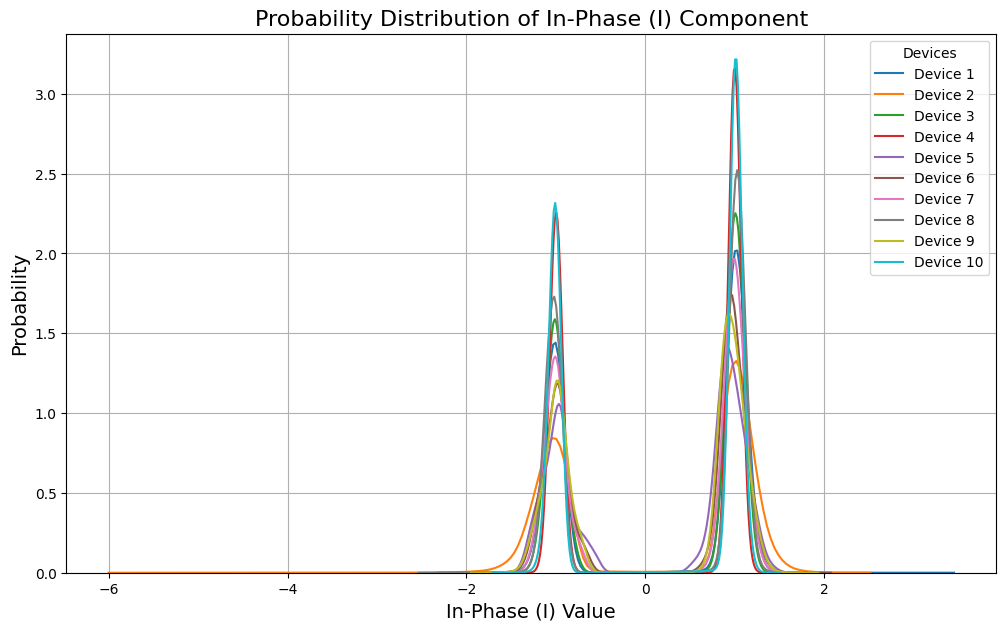


Saved 'quadrature_distribution.png'


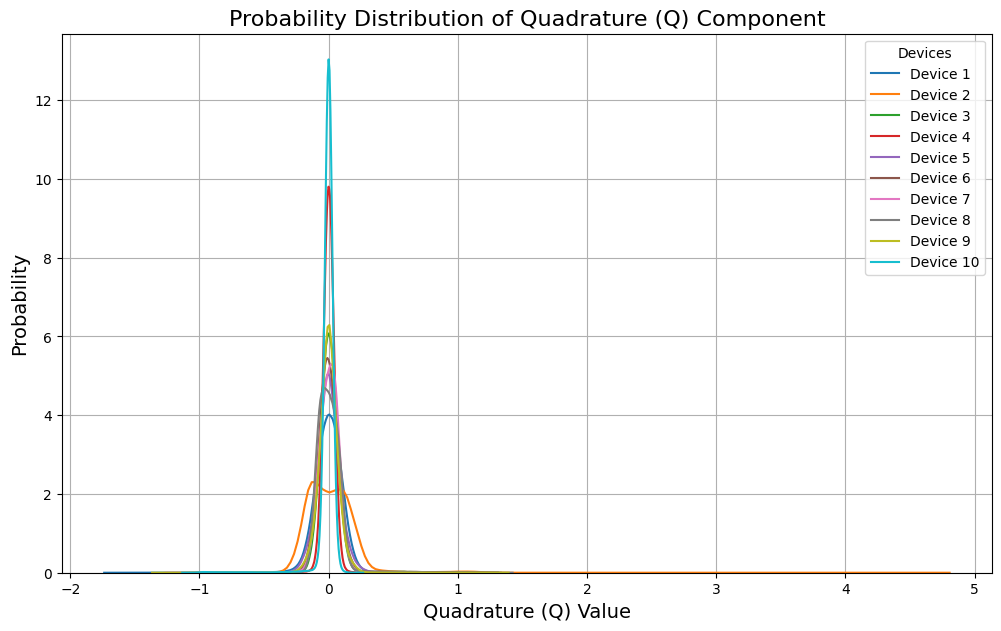

In [6]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd

# --- 1. Load All Raw Data ---
dataset_path = "E:\\RF FINGERPRINTING\\dataset\\"
all_device_files = [f"Device_{i}.mat" for i in range(1, 11)]
all_i_data = []
all_q_data = []
device_labels = []

print("Loading data for distribution plots...")
for i, file_name in enumerate(all_device_files):
    file_path = os.path.join(dataset_path, file_name)
    mat_data = scipy.io.loadmat(file_path)['headerIQMatrix'] # Shape (19920, 72)
    
    # Flatten all 72 samples from all 19920 frames into one long array
    # This gives us the complete distribution for the device
    i_data = np.real(mat_data).flatten() # Shape (19920 * 72,)
    q_data = np.imag(mat_data).flatten()
    
    all_i_data.append(i_data)
    all_q_data.append(q_data)
    device_labels.append(f"Device {i+1}")
    print(f"Loaded and flattened {file_name}")

# --- 2. Plot In-Phase (I) Distribution (like Figure 6) ---
plt.figure(figsize=(12, 7))
ax1 = plt.gca()
for i in range(len(all_i_data)):
    # Create a KDE plot for each device's I-data
    sns.kdeplot(all_i_data[i], label=device_labels[i], ax=ax1, clip=(-6, 4))

ax1.set_title('Probability Distribution of In-Phase (I) Component', fontsize=16)
ax1.set_xlabel('In-Phase (I) Value', fontsize=14)
ax1.set_ylabel('Probability', fontsize=14)
ax1.legend(title='Devices', fontsize=10)
ax1.grid(True)
plt.savefig('in_phase_distribution.png')
print("\nSaved 'in_phase_distribution.png'")
plt.show()


# --- 3. Plot Quadrature (Q) Distribution (like Figure 7) ---
plt.figure(figsize=(12, 7))
ax2 = plt.gca()
for i in range(len(all_q_data)):
    # Create a KDE plot for each device's Q-data
    sns.kdeplot(all_q_data[i], label=device_labels[i], ax=ax2, clip=(-2, 5))

ax2.set_title('Probability Distribution of Quadrature (Q) Component', fontsize=16)
ax2.set_xlabel('Quadrature (Q) Value', fontsize=14)
ax2.set_ylabel('Probability', fontsize=14)
ax2.legend(title='Devices', fontsize=10)
ax2.grid(True)
plt.savefig('quadrature_distribution.png')
print("\nSaved 'quadrature_distribution.png'")
plt.show()